# Почему ухудшилась LightGBM v1

Модель и порог уже выбраны на старой validation. Теперь посмотрим на первый production-like batch за февраль–апрель и попробуем понять, почему качество снизилось.

## 1. Загрузка модели и данных

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import (
    average_precision_score,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

preprocessor = joblib.load(ROOT / "models/preprocessor.joblib")
model = joblib.load(ROOT / "models/lightgbm_v1.joblib")

with (ROOT / "models/lightgbm_v1_metadata.json").open(encoding="utf-8") as file:
    metadata = json.load(file)

train = pd.read_parquet(ROOT / "data/processed/train.parquet")
validation = pd.read_parquet(ROOT / "data/processed/validation.parquet")
new_batch = pd.read_parquet(ROOT / "data/processed/test.parquet")

In [2]:
def prepare_data(data):
    X = data.drop(columns=metadata["drop_cols"]).copy()
    for column in metadata["categorical_cols"]:
        X[column] = X[column].astype("object").where(X[column].notna(), np.nan)
    return preprocessor.transform(X)


def period_metrics(data):
    probabilities = model.predict_proba(prepare_data(data))[:, 1]
    predictions = (probabilities >= metadata["threshold"]).astype(int)
    target = data["is_canceled"]

    return {
        "precision": precision_score(target, predictions, zero_division=0),
        "recall": recall_score(target, predictions, zero_division=0),
        "roc_auc": roc_auc_score(target, probabilities),
        "pr_auc": average_precision_score(target, probabilities),
    }, predictions

## 2. Качество на новом batch

In [3]:
validation_metrics, _ = period_metrics(validation)
new_batch_metrics, new_batch_predictions = period_metrics(new_batch)

quality_comparison = pd.DataFrame(
    [validation_metrics, new_batch_metrics],
    index=["validation", "february–april"],
)
quality_comparison.round(3)

,precision,recall,roc_auc,pr_auc
validation,0.70,0.907,0.926,0.900
february–april,0.61,0.864,0.885,0.784


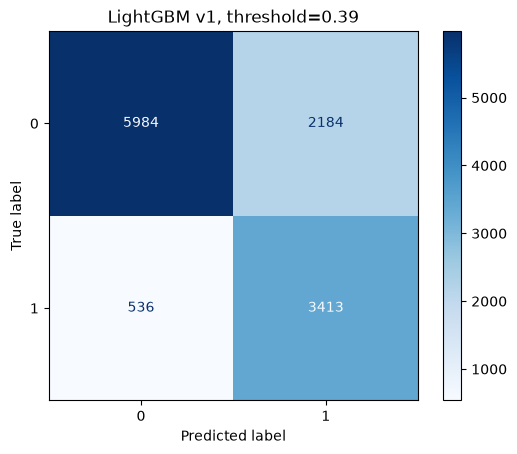

In [4]:
ConfusionMatrixDisplay.from_predictions(
    new_batch["is_canceled"],
    new_batch_predictions,
    cmap="Blues",
)
plt.title(f"LightGBM v1, threshold={metadata['threshold']:.2f}")
plt.show()

Precision заметно снизилась, поэтому бизнес-условие больше не выполняется. Recall всё ещё высокий, но менеджеры получили бы слишком много ложных срабатываний.

Менять порог по этому же batch нельзя: тогда проверка перестанет быть честной.

## 3. Data drift

In [5]:
drift_summary = pd.DataFrame({
    "validation": {
        "cancellation_rate": validation["is_canceled"].mean(),
        "lead_time_median": validation["lead_time"].median(),
        "adr_median": validation["adr"].median(),
        "non_refund_share": validation["deposit_type"].eq("Non Refund").mean(),
    },
    "february–april": {
        "cancellation_rate": new_batch["is_canceled"].mean(),
        "lead_time_median": new_batch["lead_time"].median(),
        "adr_median": new_batch["adr"].median(),
        "non_refund_share": new_batch["deposit_type"].eq("Non Refund").mean(),
    },
})
drift_summary.round(3)

,validation,february–april
cancellation_rate,0.393,0.326
lead_time_median,77.000,47.000
adr_median,93.500,117.000
non_refund_share,0.152,0.043


Входные данные действительно изменились: медианный `lead_time` стал меньше, ADR вырос, а `Non Refund` встречается намного реже. Это обычный data drift.

Но одного изменения распределений недостаточно, чтобы объяснить падение качества. Важно ещё проверить, сохранилась ли связь этих признаков с target.

## 4. Как изменилась связь feature → target

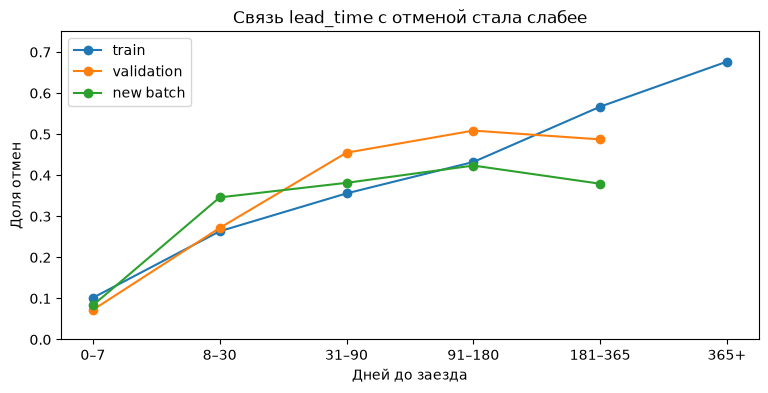

In [6]:
periods = {
    "train": train,
    "validation": validation,
    "new batch": new_batch,
}

lead_time_bins = [-1, 7, 30, 90, 180, 365, np.inf]
lead_time_labels = ["0–7", "8–30", "31–90", "91–180", "181–365", "365+"]
lead_time_relationship = []

for period, data in periods.items():
    groups = pd.cut(
        data["lead_time"],
        bins=lead_time_bins,
        labels=lead_time_labels,
    )
    rates = data.groupby(groups, observed=True)["is_canceled"].mean()
    lead_time_relationship.append(rates.rename(period))

lead_time_relationship = pd.concat(lead_time_relationship, axis=1)
lead_time_relationship.plot(marker="o", figsize=(9, 4))
plt.title("Связь lead_time с отменой стала слабее")
plt.xlabel("Дней до заезда")
plt.ylabel("Доля отмен")
plt.ylim(0, 0.75)
plt.show()

In [7]:
relationship_rows = []

for period, data in periods.items():
    previous_rate = (
        data.assign(has_previous_cancellation=data["previous_cancellations"].gt(0))
        .groupby("has_previous_cancellation")["is_canceled"]
        .mean()
    )
    deposit_rate = data.groupby("deposit_type")["is_canceled"].mean()

    relationship_rows.append({
        "period": period,
        "previous_cancel = 0": previous_rate.get(False),
        "previous_cancel > 0": previous_rate.get(True),
        "No Deposit": deposit_rate.get("No Deposit"),
        "Non Refund": deposit_rate.get("Non Refund"),
    })

relationship_table = pd.DataFrame(relationship_rows).set_index("period")
relationship_table.round(3)

,previous_cancel = 0,previous_cancel > 0,No Deposit,Non Refund
period,,,,
train,0.334,0.957,0.284,0.992
validation,0.394,0.162,0.284,0.997
new batch,0.328,0.076,0.295,1.000


На train и validation большой `lead_time` хорошо отделял рискованные брони. В новом batch рост после 90 дней почти исчез.

С историей клиента изменение началось ещё раньше: на train предыдущая отмена была очень сильным сигналом, но уже на validation и новом batch таких клиентов мало и отменяют они заметно реже.

У `Non Refund` связь с target сохранилась, зато сама категория стала встречаться реже. Получается, поменялись и распределения признаков, и некоторые связи `feature → target`. Это похоже на concept drift, но по одному batch правильнее считать это рабочей гипотезой.

## 5. Feature importance и SHAP

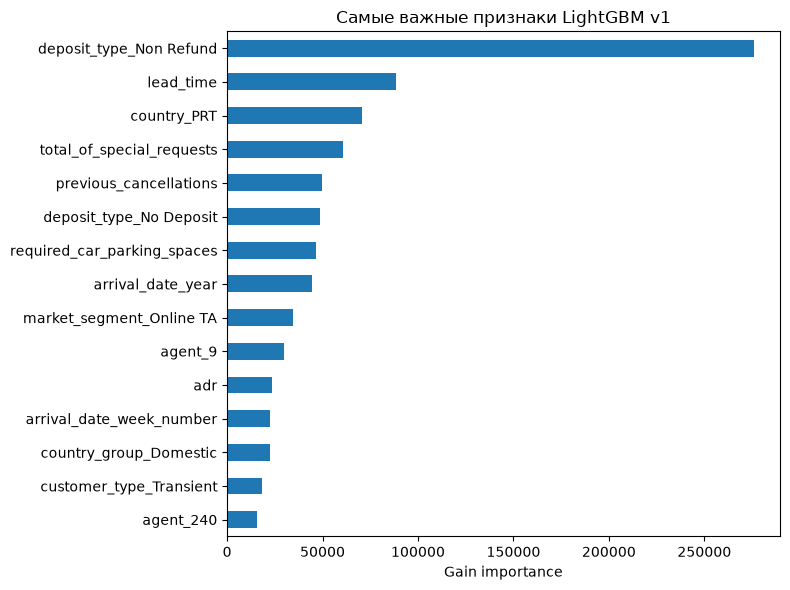

In [8]:
feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in preprocessor.get_feature_names_out()
]
feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": model.booster_.feature_importance(importance_type="gain"),
    })
    .sort_values("importance", ascending=False)
    .head(15)
    .sort_values("importance")
)

feature_importance.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6),
    legend=False,
)
plt.title("Самые важные признаки LightGBM v1")
plt.xlabel("Gain importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [9]:
rng = np.random.default_rng(42)
explainer = shap.TreeExplainer(model)
shap_by_period = {}

for period, data in {
    "validation": validation,
    "new batch": new_batch,
}.items():
    transformed = prepare_data(data)
    sample_indices = rng.choice(
        transformed.shape[0],
        size=min(1500, transformed.shape[0]),
        replace=False,
    )
    sample = transformed[sample_indices]
    if hasattr(sample, "toarray"):
        sample = sample.toarray()

    sample = pd.DataFrame(sample, columns=feature_names)
    shap_by_period[period] = (sample, explainer(sample))

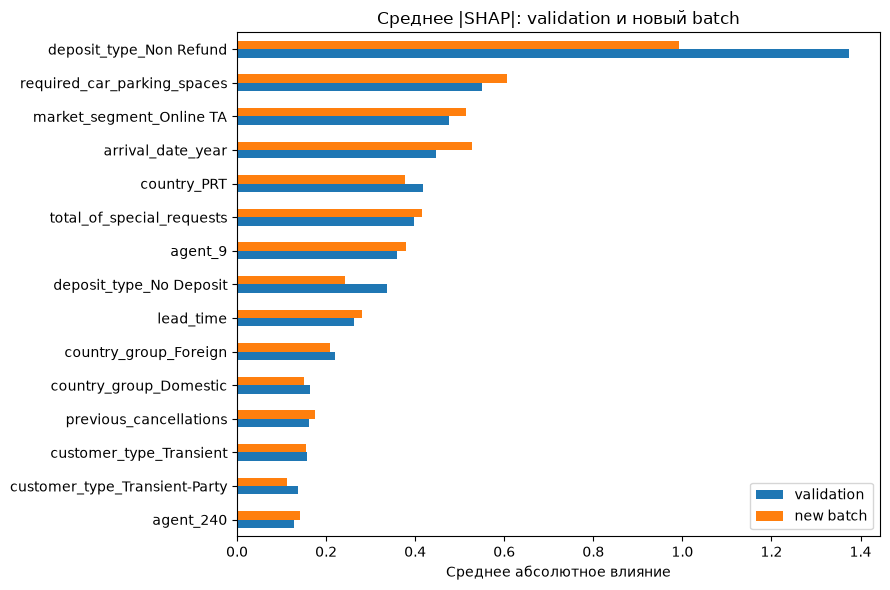

In [10]:
shap_importance = pd.DataFrame({
    period: np.abs(values.values).mean(axis=0)
    for period, (_, values) in shap_by_period.items()
}, index=feature_names)

top_shap_features = shap_importance.max(axis=1).nlargest(15).index
shap_importance.loc[top_shap_features].sort_values("validation").plot(
    kind="barh",
    figsize=(9, 6),
)
plt.title("Среднее |SHAP|: validation и новый batch")
plt.xlabel("Среднее абсолютное влияние")
plt.ylabel("")
plt.tight_layout()
plt.show()

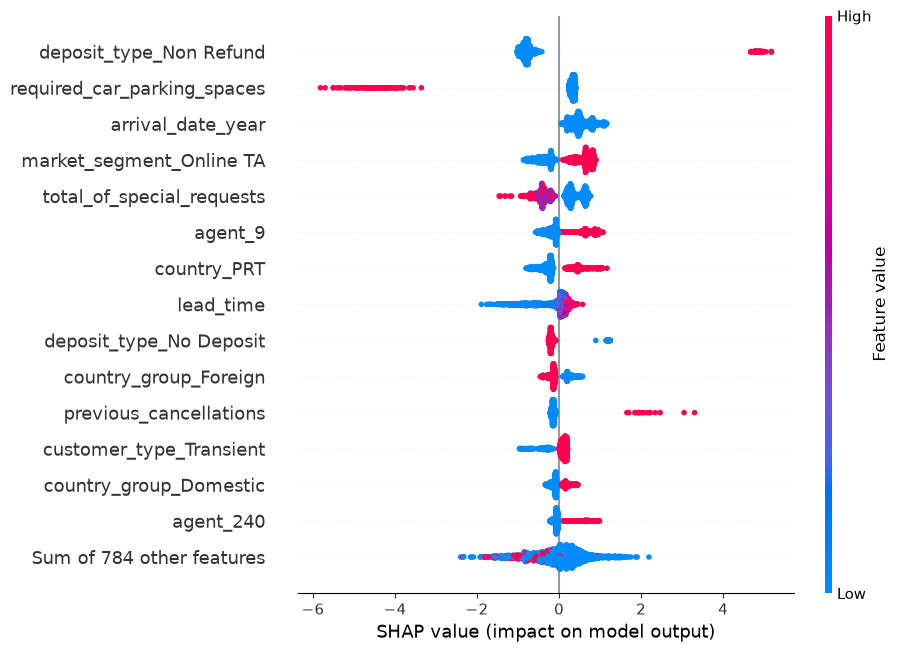

In [11]:
new_batch_sample, new_batch_shap = shap_by_period["new batch"]
shap.plots.beeswarm(new_batch_shap, max_display=15)

По SHAP видно, что вклад признаков на новом batch перераспределился. Это хорошо дополняет предыдущие наблюдения, но само по себе concept drift не доказывает: SHAP может меняться и из-за корреляций между признаками.

## Итог

На новых данных поменялись не только распределения признаков, но и часть связей с отменой. Поэтому закономерности, на которых хорошо работала LightGBM, стали хуже переноситься на следующий период.

После появления ответов за февраль и март уже можно попробовать несколько простых retraining-стратегий. Апрель при этом останется отдельным периодом для выбора кандидата.